# Using the $\sigma(M)$ emulator

## How to call the emulator and a comparison between the emulated and analytical fucntion

In [32]:
from halox import halo, cosmology, hmf, bias, emus, lss
import matplotlib.pyplot as plt
import jax.numpy as jnp
plt.rcParams['axes.titlesize'] = 32
plt.rcParams['axes.labelsize'] = 24
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams['figure.labelsize'] = 24
plt.rcParams['legend.fontsize'] = 24
plt.rcParams['lines.linewidth'] = 4

## Building the cosmology and mass range

In [33]:
# Create a Planck 2018 cosmology
cosmo = cosmology.Planck18()
print(f"Hubble parameter h = {cosmo.h}")
print(f"Matter density Ω_m = {cosmo.Omega_m}")
print(f"Baryon density Ω_b = {cosmo.Omega_b}")
print(f"Cold dark matter density Ω_c = {cosmo.Omega_c}")
print(f"Power spectrum normalization σ_8 = {cosmo.sigma8}")

# Mass range from 10^10 to 10^16 h^-1 M_sun
M = jnp.logspace(11, 16, 100)
z = 0.0
delta_c = 200.0

Hubble parameter h = 0.6766
Matter density Ω_m = 0.30964
Baryon density Ω_b = 0.04897
Cold dark matter density Ω_c = 0.26067
Power spectrum normalization σ_8 = 0.8102


## Calling the emualted versus non-emulated functions

To use the emulated value of $\sigma(M)$, instantiate an emulator and pass it into the sigma_M function. 

The emulator object here is using the default network weights and training ranges. If you have another weight file from an emulator you have trained (see notebook sigma_emulation.ipynb for details on how to do this) you can pass this into the emulator instantiation as the kwarg weight_file.

In [34]:
emu = emus.sigmaM.SigmaMEmulator()
sigma_fid = lss.sigma_M(M, z, cosmo)
sigma_emu = lss.sigma_M(M, z, cosmo, emu = emu)

## Comparison

Below is a comparison of $\sigma(M)$ calculations, followed by a comparison of HMF and Halo Bias using emulated values of $\sigma(M)$.

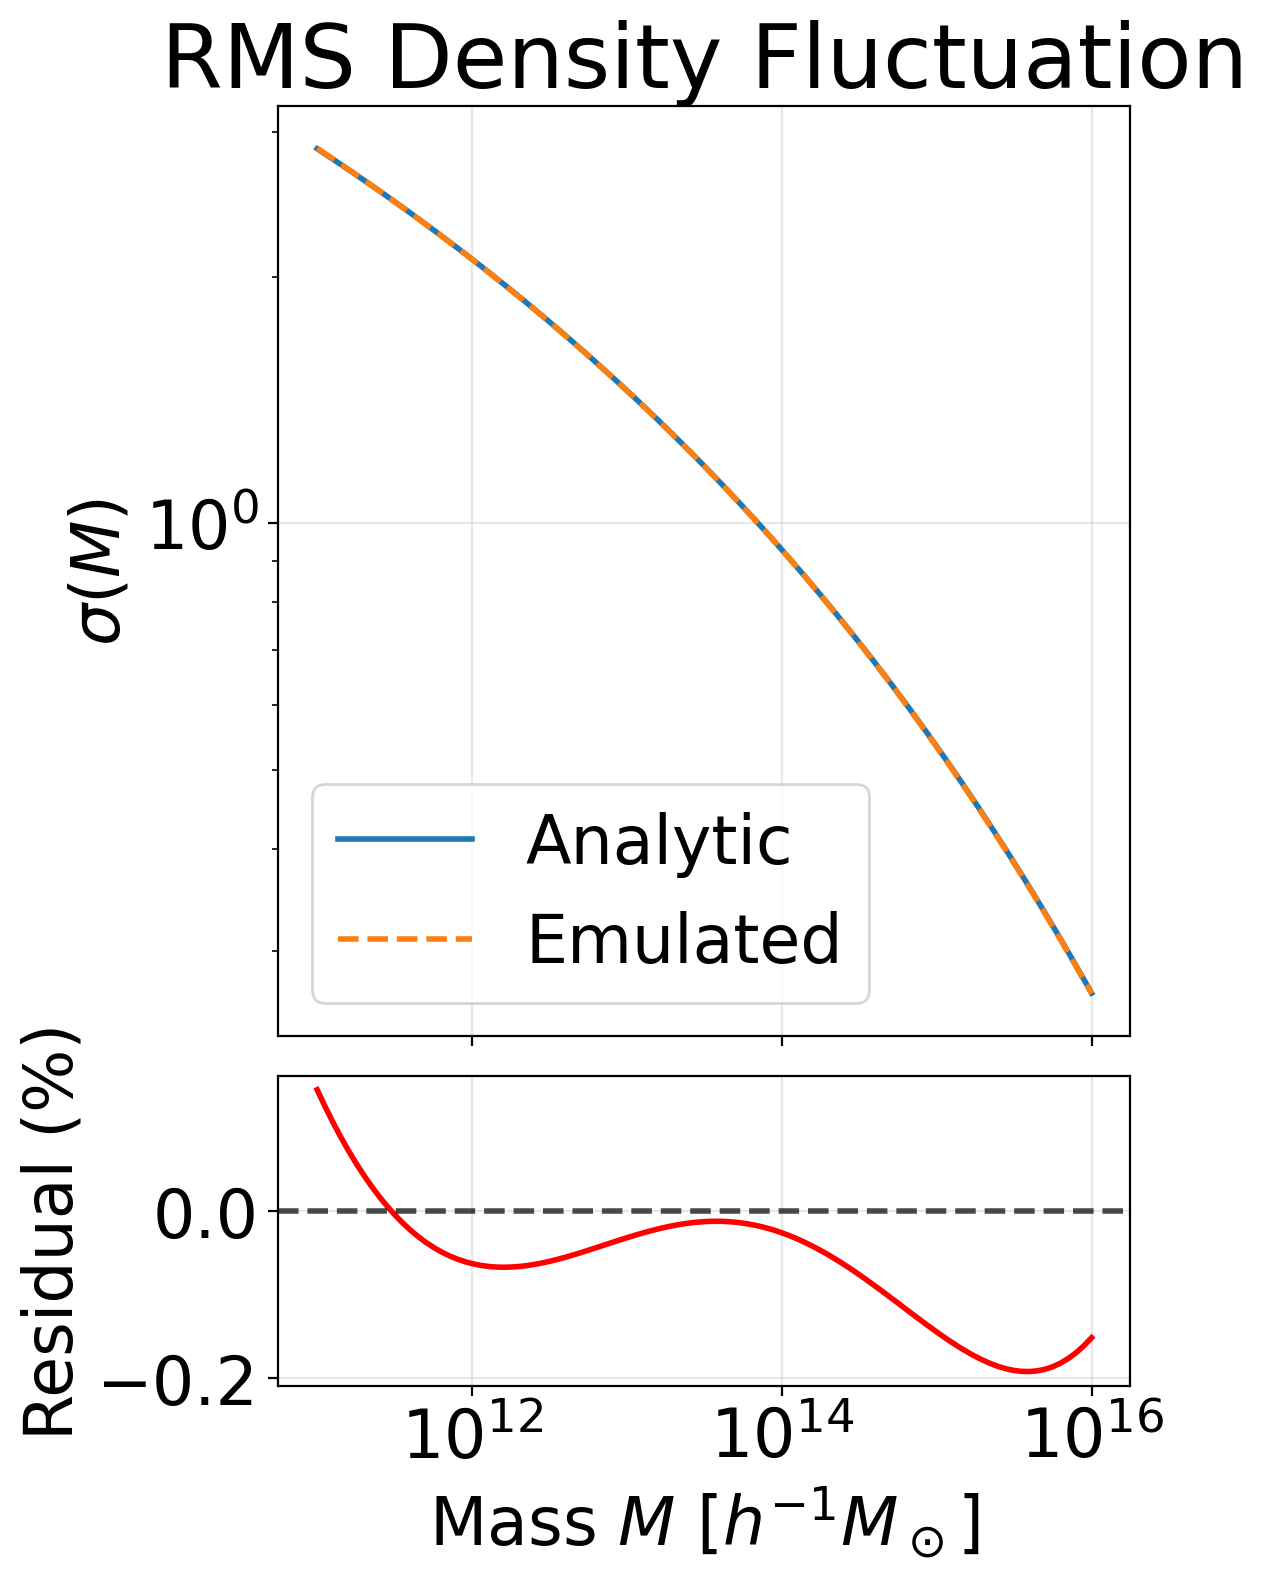

In [35]:
# fractional residuals
residuals = (sigma_emu - sigma_fid) / sigma_fid * 100

fig, axs = plt.subplots(
    2, 1, figsize=(6, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}, dpi = 200
)

# --- Top: sigma(M) ---
axs[0].plot(M, sigma_fid, label="Analytic", lw=2)
axs[0].plot(M, sigma_emu, "--", label="Emulated", lw=2)

axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_ylabel(r"$\sigma(M)$")
axs[0].set_title(r"RMS Density Fluctuation")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# --- Bottom: residuals ---
axs[1].plot(M, residuals, lw=2, color = "red")

axs[1].axhline(0.0, color="black", linestyle="--", alpha=0.7, lw = 2)

axs[1].set_xscale("log")
axs[1].set_ylabel("Residual (%)")
axs[1].set_xlabel(r"Mass $M$ [$h^{-1} M_\odot$]")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()

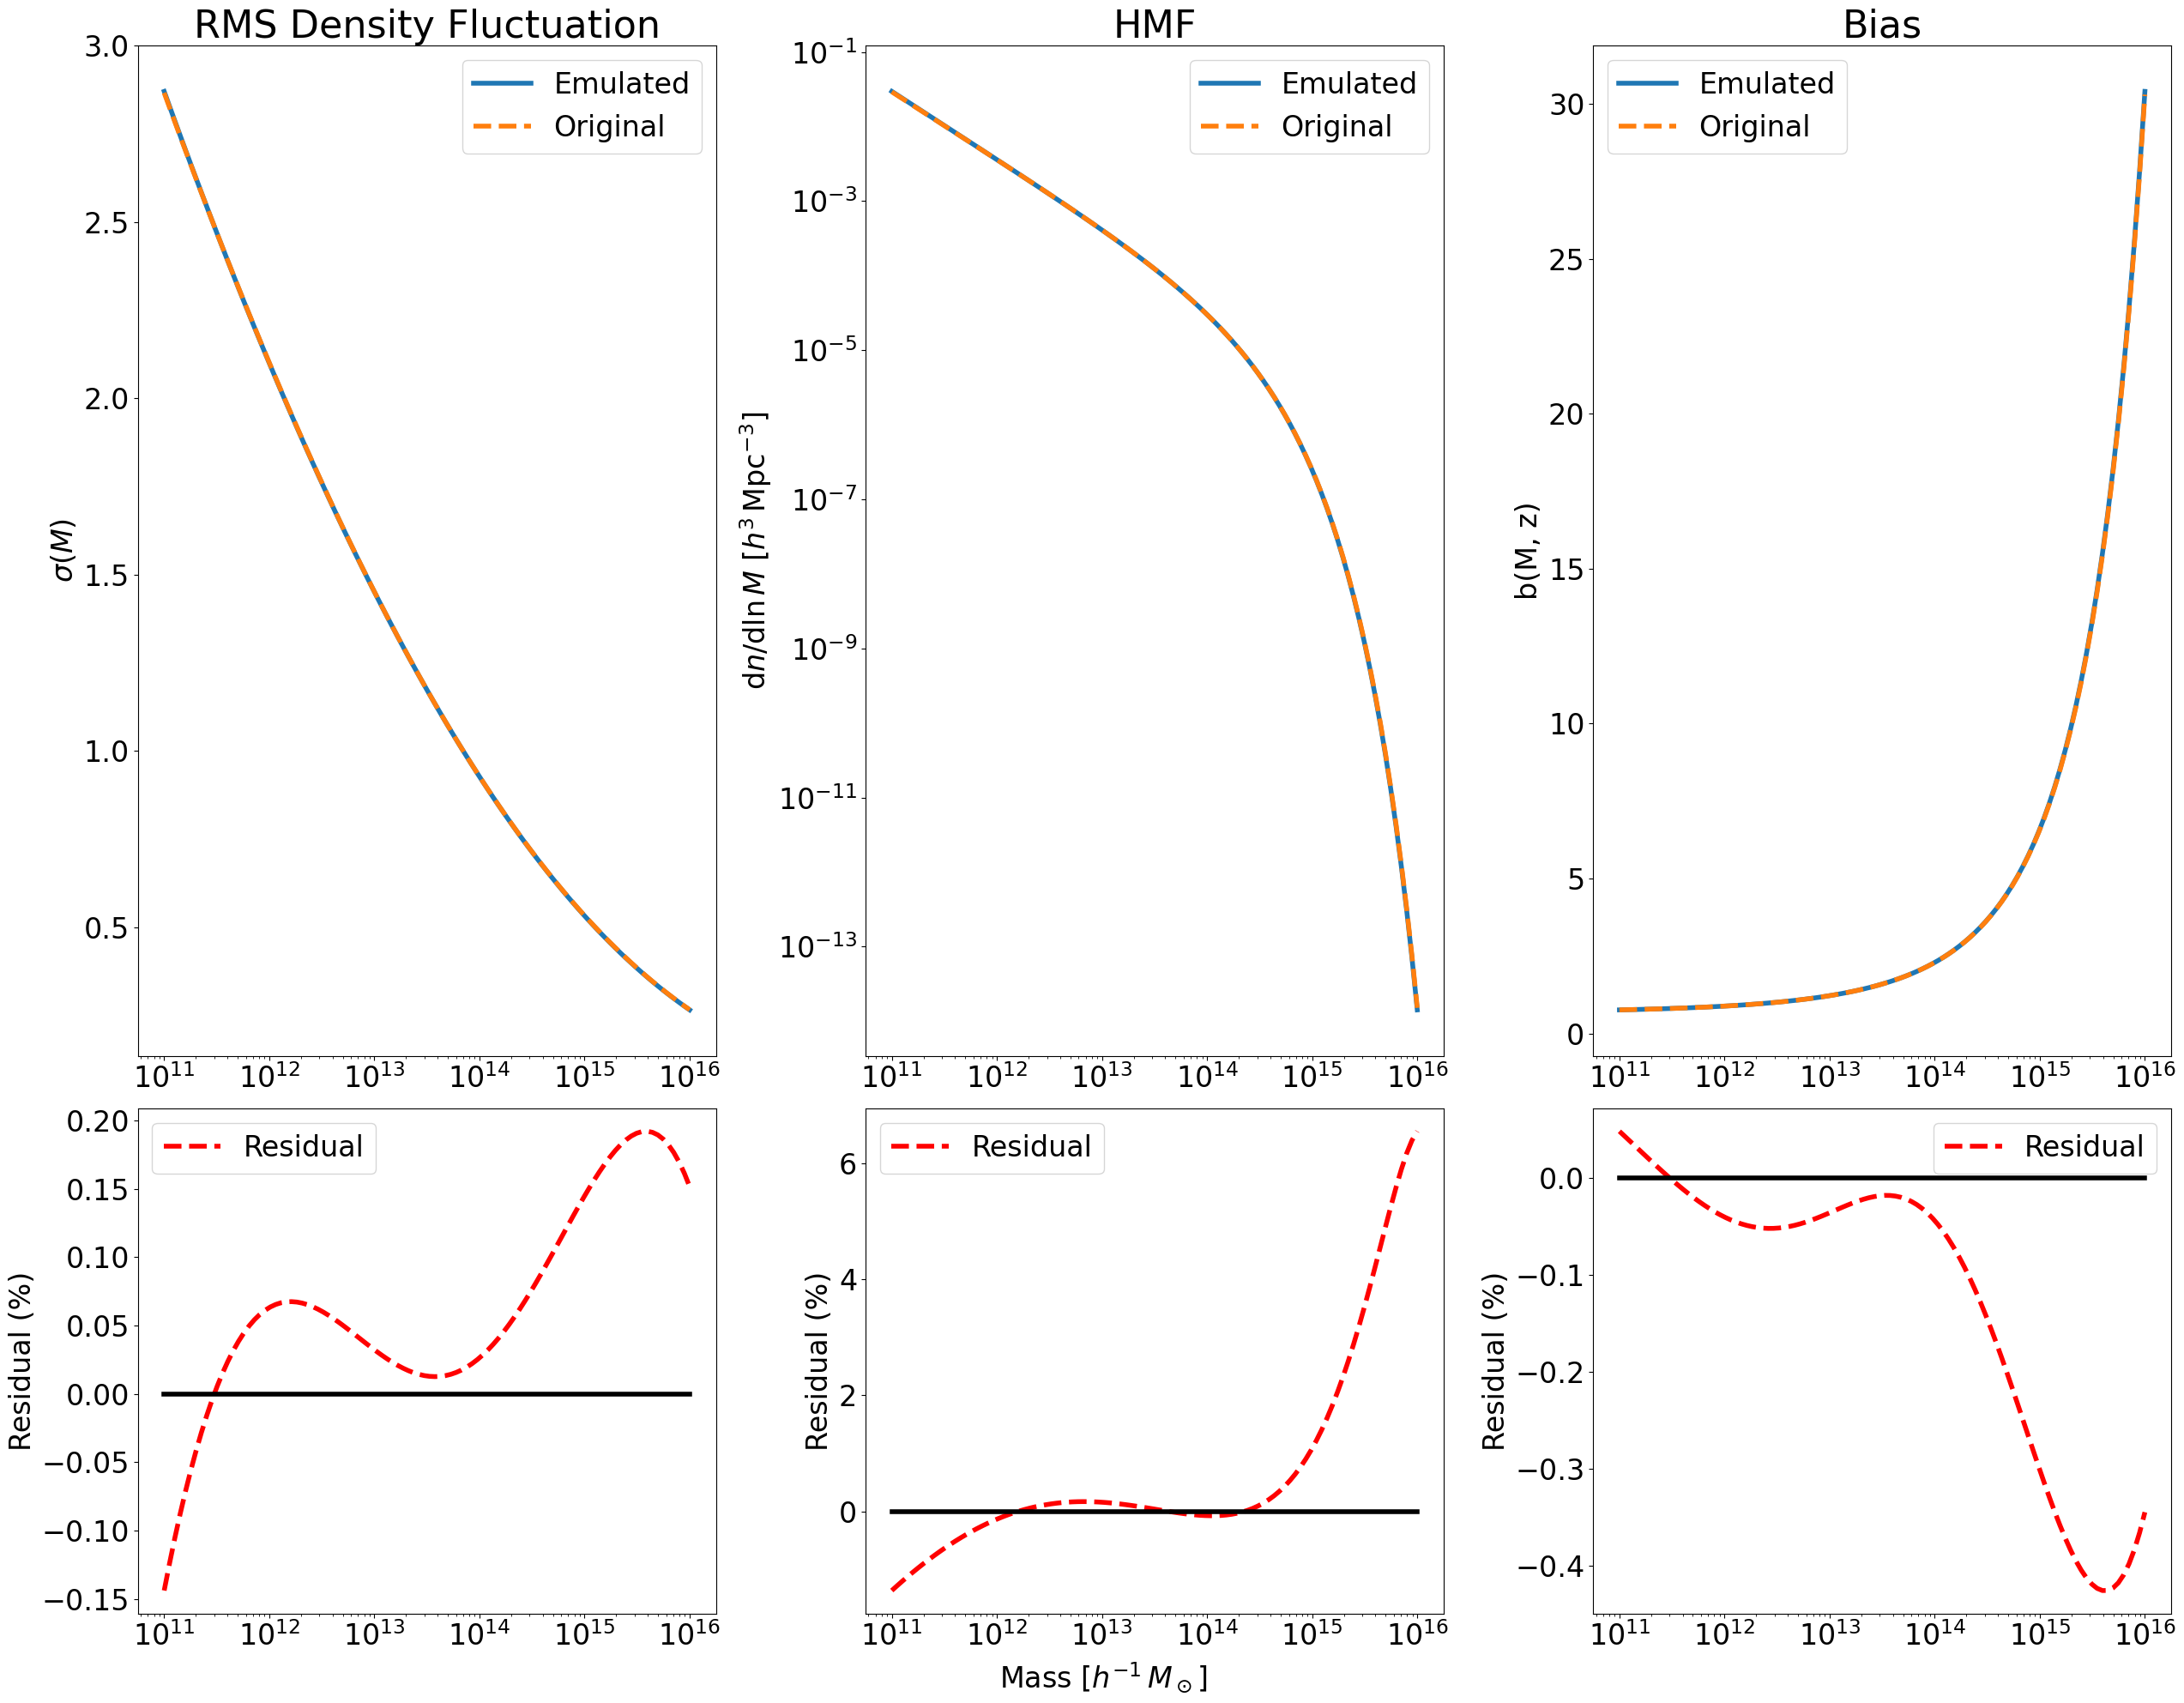

In [36]:

# Compute the mass function
dn_dlnM = hmf.tinker08_mass_function(M, z, cosmo, delta_c)
dn_dlnM_emu = hmf.tinker08_mass_function(M, z, cosmo, delta_c, emu = emu)
hbias = bias.tinker10_bias(M, z, cosmo, delta_c)
hbias_emu = bias.tinker10_bias(M, z, cosmo, delta_c, emu = emu)

fig2, axs2 = plt.subplots(2,3, figsize = (20*1.27,20), gridspec_kw={'height_ratios': [2, 1]})

fig2.supxlabel(r"Mass [$h^{-1} \, M_\odot$]")

axs2[0][0].set_ylabel(r"$\sigma(M)$")
axs2[0][0].set_title(r"RMS Density Fluctuation")
axs2[0][0].set_xscale("log")
axs2[0][0].set_yscale("linear")
axs2[0][0].plot(M, sigma_emu, label="Emulated")
axs2[0][0].plot(M, sigma_fid, "--", label="Original")
axs2[0][0].legend()

axs2[1][0].set_ylabel("Residual (%)")
axs2[1][0].set_xscale("log")
axs2[1][0].set_yscale("linear")
axs2[1][0].plot(M, ((sigma_fid/sigma_emu)-1)*100, color = "red", ls = "--", label = "Residual")
axs2[1][0].plot(M, jnp.zeros_like(M), ls = "-", color = "black")
axs2[1][0].legend()

axs2[0][1].set_title("HMF")
axs2[0][1].set_ylabel(r"${\rm d}n/{\rm d}\ln M$ [$h^3 \, {\rm Mpc}^{-3}$]")
axs2[0][1].set_xscale("log")
axs2[0][1].set_yscale("log")
axs2[0][1].plot(M, dn_dlnM_emu, ls = "-", label = "Emulated")
axs2[0][1].plot(M, dn_dlnM, ls = "--", label = "Original")
axs2[0][1].legend()

axs2[1][1].set_ylabel("Residual (%)")
axs2[1][1].set_xscale("log")
axs2[1][1].set_yscale("linear")
axs2[1][1].plot(M, ((dn_dlnM/dn_dlnM_emu)-1)*100, color = "red", ls = "--", label = "Residual")
axs2[1][1].plot(M, jnp.zeros_like(M), ls = "-", color = "black")
axs2[1][1].legend()

axs2[0][2].set_title("Bias")
axs2[0][2].set_ylabel(r"b(M, z)")
axs2[0][2].set_xscale("log")
axs2[0][2].set_yscale("linear")
axs2[0][2].plot(M, hbias_emu, ls = "-", label = "Emulated")
axs2[0][2].plot(M, hbias, ls = "--", label = "Original")
axs2[0][2].legend()

axs2[1][2].set_ylabel("Residual (%)")
axs2[1][2].set_xscale("log")
axs2[1][2].set_yscale("linear")
axs2[1][2].plot(M, ((hbias/hbias_emu)-1)*100, color = "red", ls = "--", label = "Residual")
axs2[1][2].plot(M, jnp.zeros_like(M), ls = "-", color = "black")
axs2[1][2].legend()

fig2.tight_layout()

